In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler

import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import f_regression

In [2]:
data=pd.read_excel("/kaggle/input/all-data/data - Copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']
X_selected=['p','v','h','t']

data2=pd.read_excel('/kaggle/input/all-data/synthetic_data_gmm_1400.xlsx')
data2 = data2.replace({',': '.'}, regex=True)

data2.columns=['p','v','h','t','Ra']

data3 = pd.read_csv("/kaggle/input/all-data/synthetic_data_gans_filtre.csv", delimiter=',')
data3 = data3.replace({',': '.'}, regex=True)
data3.columns=['p','v','h','t','Ra']

df1 = data[['p', 'v', 'h', 't', 'Ra']]
df2 = data2[['p', 'v', 'h', 't', 'Ra']]
df3 = data3[['p', 'v', 'h', 't', 'Ra']]


merged_data = pd.concat([df1, df2, df3], ignore_index=True)
print(merged_data.shape)  

X_merged = merged_data[X_selected].values
y_merged = merged_data[['Ra']].values


(4291, 5)


In [4]:
merged_data.describe()

,p,v,h,t,Ra
count,4291.000000,4291.000000,4291.000000,4291.000000,4291.000000
mean,189.960889,787.119186,95.517062,34.063063,9.712378
std,78.865353,244.324573,24.742655,13.473757,4.416855
min,44.336022,71.597240,36.687026,16.385326,1.101585
25%,144.952529,604.210260,79.751008,22.907884,6.705813
50%,172.675031,794.509159,91.287853,30.016912,9.519962
75%,238.067274,985.899334,110.962289,43.105115,11.256840
max,393.167844,1555.213650,200.054491,68.824275,33.281677


In [3]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5


In [4]:
data_extended =merged_data.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']


variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3})'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3])






data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']
data_extended["I(p * h^-1 * t^-1)"]=data_extended['p'] /( data_extended['v'] * data_extended['h'])
for var in variables:
    data_extended[f'I({var}^-1)'] = 1 / (data_extended[var] + 1e-6)


for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            data_extended[f'I({var1} * {var2}^-1)'] = data_extended[var1] / (data_extended[var2] + 1e-6)


for r in range(2, len(variables) + 1):
    for combo in combinations(variables, r):
        
        col_name = 'I(' + ' * '.join([f'{v}^-1' for v in combo]) + ')'
        inv_product = np.ones(len(data_extended))
        for v in combo:
            inv_product *= 1 / (data_extended[v] + 1e-6)
        data_extended[col_name] = inv_product

data_extended['p_ratio'] = data_extended['p'] / (data_extended['p'] + data_extended['v'] + data_extended['h'] + data_extended['t'] + 1e-6)
data_extended['v_ratio'] = data_extended['v'] / (data_extended['p'] + data_extended['v'] + data_extended['h'] + data_extended['t'] + 1e-6)
data_extended['h_ratio'] = data_extended['h'] / (data_extended['p'] + data_extended['v'] + data_extended['h'] + data_extended['t'] + 1e-6)
data_extended['t_ratio'] = data_extended['t'] / (data_extended['p'] + data_extended['v'] + data_extended['h'] + data_extended['t'] + 1e-6)





In [11]:
data_extended

,p,v,h,t,Ra,I(p^2),I(v^2),I(h^2),I(t^2),p:v,...,I(h^-1 * t^-1),I(p^-1 * v^-1 * h^-1),I(p^-1 * v^-1 * t^-1),I(p^-1 * h^-1 * t^-1),I(v^-1 * h^-1 * t^-1),I(p^-1 * v^-1 * h^-1 * t^-1),p_ratio,v_ratio,h_ratio,t_ratio
0,150.000000,400.000000,115.000000,25.000000,5.200000,22500.000000,1.600000e+05,13225.000000,625.000000,60000.000000,...,0.000348,1.449275e-07,6.666666e-07,2.318840e-06,8.695652e-07,5.797101e-09,0.217391,0.579710,0.166667,0.036232
1,150.000000,700.000000,115.000000,25.000000,7.900000,22500.000000,4.900000e+05,13225.000000,625.000000,105000.000000,...,0.000348,8.281573e-08,3.809524e-07,2.318840e-06,4.968944e-07,3.312629e-09,0.151515,0.707071,0.116162,0.025253
2,150.000000,1000.000000,115.000000,25.000000,11.000000,22500.000000,1.000000e+06,13225.000000,625.000000,150000.000000,...,0.000348,5.797101e-08,2.666667e-07,2.318840e-06,3.478261e-07,2.318840e-09,0.116279,0.775194,0.089147,0.019380
3,180.000000,400.000000,115.000000,25.000000,5.000000,32400.000000,1.600000e+05,13225.000000,625.000000,72000.000000,...,0.000348,1.207729e-07,5.555555e-07,1.932367e-06,8.695652e-07,4.830918e-09,0.250000,0.555556,0.159722,0.034722
4,180.000000,700.000000,115.000000,25.000000,7.300000,32400.000000,4.900000e+05,13225.000000,625.000000,126000.000000,...,0.000348,6.901311e-08,3.174603e-07,1.932367e-06,4.968944e-07,2.760524e-09,0.176471,0.686275,0.112745,0.024510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4286,371.807239,747.376044,123.094523,55.739828,23.969654,138240.622670,5.585710e+05,15152.261590,3106.928400,277879.823217,...,0.000146,2.923508e-08,6.456206e-08,3.919925e-07,1.950098e-07,5.244917e-10,0.286442,0.575783,0.094833,0.042942
4287,237.238373,714.155321,121.169498,25.688342,8.156008,56282.045478,5.100178e+05,14682.047208,659.890930,169425.046268,...,0.000321,4.871123e-08,2.297663e-07,1.354209e-06,4.498606e-07,1.896239e-09,0.216015,0.650266,0.110329,0.023390
4288,179.559588,880.789799,125.191393,28.640240,6.065145,32241.645673,7.757907e+05,15672.884758,820.263348,158154.253580,...,0.000279,5.050619e-08,2.207712e-07,1.553246e-06,3.166479e-07,1.763470e-09,0.147885,0.725419,0.103108,0.023588
4289,173.605987,368.299158,125.190196,24.898521,3.570502,30139.038556,1.356443e+05,15672.585176,619.936357,63938.938573,...,0.000321,1.249293e-07,6.281466e-07,1.847955e-06,8.710747e-07,5.017538e-09,0.250878,0.532229,0.180912,0.035981


In [5]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X = data_extended.drop(columns=['Ra'], errors='ignore')

df_log = np.log(X)
scaler=RobustScaler()
X_standardized = scaler.fit_transform(df_log)


X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_extended['Ra']

f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

anova_significant = anova_results[anova_results['p-value'] < 0.05]['Variable'].tolist()

mi_scores = mutual_info_regression(X_standardized, y)
mi_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'MI-Score': mi_scores
})

threshold = 0.1
mi_significant = mi_results[mi_results['MI-Score'] > threshold]['Variable'].tolist()

selected_vars = list(set(anova_significant) & set(mi_significant))

X_selected_vars = X[selected_vars]

print("Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :")
print(selected_vars)


Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :
['I(p^2 * t)', 'I(sqrt(h)', 'v', 'I(v * t^-1)', 'I(v^2)', 'p:v', 'I(log(h) * p)', 'I(log(p) * h)', 'p:t', 'I(h^-1 * t^-1)', 'I(p^-1 * v^-1 * h^-1)', 'h', 'p:h', 'I(sqrt(t) * v)', 'I(t * v^-1)', 'I(h * p^-1)', 'I(p^2 * v * t)', 'I(log(v) * t)', 'I(sqrt(v) * p)', 'v:h', 'I(p^2 * h)', 'I(p^-1)', 'I(log(h) * t)', 'h_ratio', 'v:h:t', 'I(h^2 * t)', 'I(p * sqrt(v))', 'I(log(t) * p)', 'I(v * h^-1)', 'I(p * v^-1)', 'p:v:h', 'p:v:t', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'v_ratio', 'I(t * p^-1)', 'I(sqrt(v)', 'I(log(h) * v)', 'I(p^-1 * h^-1 * t^-1)', 'I(p * h^-1 * t^-1)', 'I(sqrt(p) * t)', 'I(log(v) * p)', 'p', 'I(p * t^-1)', 'I(v^-1 * t^-1)', 'v:t', 'I(t^2)', 'I(t^-1)', 'I(log(p) * v)', 'I(p^2 * v)', 'I(h * t^-1)', 't', 't_ratio', 'I(sqrt(h) * t^2)', 'I(sqrt(p) * h)', 'h:t', 'I(sqrt(t) * h)', 'I(p * h^-1)', 'I(v^-1)', 'I(sqrt(p)', 'I(t * h^-1)', 'I(sqrt(v) * t)', 'I(h^-1)', 'I(sqrt(v) * h)', 'I(log(t) * h)', 'I(p^2)', 'I(h^2)', 

In [6]:
corr_matrix = X_selected_vars.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]

X_filtered = X_selected_vars.drop(columns=to_drop)

print(f"Variables supprimées car trop corrélées: {to_drop}")
print(f"Nombre de variables restantes: {X_filtered.shape[1]}")

Variables supprimées car trop corrélées: ['I(v^2)', 'I(log(h) * p)', 'I(log(p) * h)', 'p:t', 'h', 'p:h', 'I(sqrt(t) * v)', 'I(p^2 * v * t)', 'I(log(v) * t)', 'I(sqrt(v) * p)', 'v:h', 'I(p^2 * h)', 'I(p^-1)', 'I(log(h) * t)', 'v:h:t', 'I(h^2 * t)', 'I(p * sqrt(v))', 'I(log(t) * p)', 'I(v * h^-1)', 'p:v:h', 'p:v:t', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'v_ratio', 'I(sqrt(v)', 'I(log(h) * v)', 'I(p^-1 * h^-1 * t^-1)', 'I(p * h^-1 * t^-1)', 'I(sqrt(p) * t)', 'I(log(v) * p)', 'p', 'I(p * t^-1)', 'I(v^-1 * t^-1)', 'v:t', 'I(t^2)', 'I(t^-1)', 'I(log(p) * v)', 'I(p^2 * v)', 't', 't_ratio', 'I(sqrt(h) * t^2)', 'I(sqrt(p) * h)', 'h:t', 'I(sqrt(t) * h)', 'I(p * h^-1)', 'I(v^-1)', 'I(sqrt(p)', 'I(t * h^-1)', 'I(sqrt(v) * t)', 'I(h^-1)', 'I(sqrt(v) * h)', 'I(log(t) * h)', 'I(p^2)', 'I(h^2)', 'p:h:t', 'I(p^-1 * v^-1 * t^-1)', 'I(v^2 * t)', 'I(h * v^-1)', 'I(p^-1 * h^-1)', 'I(v * p^-1)', 'I(sqrt(t)', 'I(p^-1 * v^-1)', 'I(sqrt(t) * p)', 'I(sqrt(h) * t)', 'I(p^-1 * t^-1)', 'I(p * h * sqrt(t))', 'I(p^2 * v *

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [7]:

X=X_filtered.values
epsilon = 1e-6
df_log = np.log(X)



scaler=RobustScaler()
X_scaled =scaler.fit_transform(df_log)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_merged, 
    test_size=0.30, 
    random_state=42,shuffle=True)
y_train_bc=box_cox_fun(y_train)
y_test_bc=box_cox_fun(y_test)

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, PReLU, Dropout
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# ---------- Choix de l'optimizer ----------
def get_optimizer(name, lr):
    return {
        'adam': Adam(learning_rate=lr),
        'adamw': AdamW(learning_rate=lr, weight_decay=1e-4),
        'rmsprop': RMSprop(learning_rate=lr),
        
    }[name.lower()]

# ---------- Construction du modèle ----------
def build_model(input_dim, optimizer_name, learning_rate, variant="deep"):
    opt = get_optimizer(optimizer_name, learning_rate)

    layers = []
    if variant == "deep":
        layers = [
            tf.keras.Input(shape=(input_dim,)),
            Dense(512), BatchNormalization(), PReLU(),
            Dense(256), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(128), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(64), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(32), BatchNormalization(), PReLU(), Dropout(0.3),
            Dense(16), BatchNormalization(), PReLU(), Dropout(0.2)
         ]

        

    layers.append(Dense(1, activation='relu'))

    model = Sequential(layers)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# ---------- Callbacks ----------
early_stopping = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, verbose=0)

# ---------- Grilles d’hyperparamètres ----------
optimizers = ['adam', 'adamw', 'rmsprop']
learning_rates = [0.001, 0.005,0.01]
batch_sizes = [ 64,128,256]
architectures = ['deep']

# ---------- Recherche ----------
best_score = -np.inf  
best_params = {}
best_model = None
results = []

for arch in architectures:
    for opt_name in optimizers:
        for lr in learning_rates:
            for bs in batch_sizes:
                print(f"\n🔵 Test: arch={arch}, optimizer={opt_name}, lr={lr}, batch={bs}")

                model = build_model(X_train.shape[1], opt_name, lr, arch)
                
                history = model.fit(
                    X_train, y_train_bc,
                    epochs=5000,
                    batch_size=bs,
                    validation_data=(X_test, y_test_bc),
                    verbose=0,
                    callbacks=[early_stopping, reduce_lr]
                )
                
                preds = model.predict(X_test).squeeze()
                preds = inverse_box_cox(preds)
                
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                mae = mean_absolute_error(y_test, preds)
                r2 = r2_score(y_test, preds)
                
                results.append({
                    'arch': arch,
                    'optimizer': opt_name,
                    'learning_rate': lr,
                    'batch_size': bs,
                    'RMSE': rmse,
                    'MAE': mae,
                    'R2': r2
                })
                
                if r2 > best_score:
                    best_score = r2
                    best_params = {'arch': arch, 'optimizer': opt_name, 'learning_rate': lr, 'batch_size': bs}
                    best_model = model

# ---------- Résultats ----------
results_df = pd.DataFrame(results)
print("\n📊 Résumé des tests (classé par R² décroissant) :")
print(results_df.sort_values('R2', ascending=False))

print("\n✅ Meilleurs hyperparamètres trouvés :")
print(best_params)
print(f"🎯 Meilleur R² : {best_score:.4f}")

# ---------- Prédictions finales ----------
y_pred_final = best_model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)
print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")





🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=64
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=128
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.001, batch=256
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=64
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=128
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.005, batch=256
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=64
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=128
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

🔵 Test: arch=deep, optimizer=adam, lr=0.01, batch=256
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

🔵 Test: arch=deep, optimizer=adamw, lr=0.001, batch=64
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

🔵 Test: arch=deep, optimizer=adamw, lr=0.001, batch=128

In [20]:
best_model.save("models_pvht_anova_gmm_gan/best_model.h5")

In [21]:

from sklearn.ensemble import RandomForestRegressor
import optuna


def objective(trial):
   
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30, step=1),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }
    
    
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train_bc.ravel())
    
    y_pred_bc_rf = rf.predict(X_test)
    y_pred_rf = inverse_box_cox(y_pred_bc_rf)
    
    
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    
    
    return rmse_rf


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=100)  


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-19 09:06:29,721] A new study created in memory with name: no-name-cd9eecae-28b2-4d03-b02f-06b9d5d27410
[I 2025-05-19 09:06:32,243] Trial 0 finished with value: 1.453658824099787 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 1.453658824099787.
[I 2025-05-19 09:06:46,341] Trial 1 finished with value: 2.324530917372604 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 1.453658824099787.
[I 2025-05-19 09:07:02,596] Trial 2 finished with value: 1.7930433543895172 and parameters: {'n_estimators': 400, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 1.453658824099787.
[I 2025-05-19 09:07:05,089] Trial 3 finished with value: 1.524503305772859 and pa

Best trial:
FrozenTrial(number=61, state=1, values=[1.3513101710443087], datetime_start=datetime.datetime(2025, 5, 19, 9, 15, 20, 496332), datetime_complete=datetime.datetime(2025, 5, 19, 9, 15, 39, 49525), params={'n_estimators': 600, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=100), 'max_depth': IntDistribution(high=30, log=False, low=5, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=61, value=None)
Best params:
{'n_estimators': 600, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}


In [23]:

rf = RandomForestRegressor(bootstrap= True, max_depth=17, max_features=None, min_samples_leaf= 1, min_samples_split= 3, n_estimators= 600)


rf.fit(X_train, y_train_bc.ravel())
y_pred_bc_rf = rf.predict(X_test)
y_pred_rf = inverse_box_cox(y_pred_bc_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"mape: {mape_rf:.4f}")

R2: 0.9064
RMSE: 1.3578
MAE: 0.7523
mape: 48.0582


In [24]:
import joblib
joblib.dump(rf, 'models_pvht_anova_gmm_gan/rf.joblib')

['models_pvht_anova_gmm_gan/rf.joblib']

In [25]:

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform


param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(1e-4, 0.1),
    'n_estimators': randint(200, 1000),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
    'scale_pos_weight': uniform(1, 2),
    'max_delta_step': randint(1, 10),
    'min_split_loss': uniform(0, 0.3)
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50, 
    eval_metric='rmse'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=3000,               
    cv=5,                     
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_bc,
    test_size=0.15,
    random_state=42
)

random_search.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_model_xgb = random_search.best_estimator_
print(best_model)
y_pred = best_model.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")


Fitting 5 folds for each of 3000 candidates, totalling 15000 fits
<Sequential name=sequential_44, built=True>
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2: 0.9452
RMSE: 1.0388
MAE: 0.6391


In [26]:
joblib.dump(best_model_xgb, 'models_pvht_anova_gmm_gan/xgb_best_model.joblib')

['models_pvht_anova_gmm_gan/xgb_best_model.joblib']


--- Meilleur SVR trouvé ---
Best params: {'C': 5, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'rbf'}
R2: 0.9287
RMSE: 1.1848
MAE: 0.6856
MAPE: 48.61%


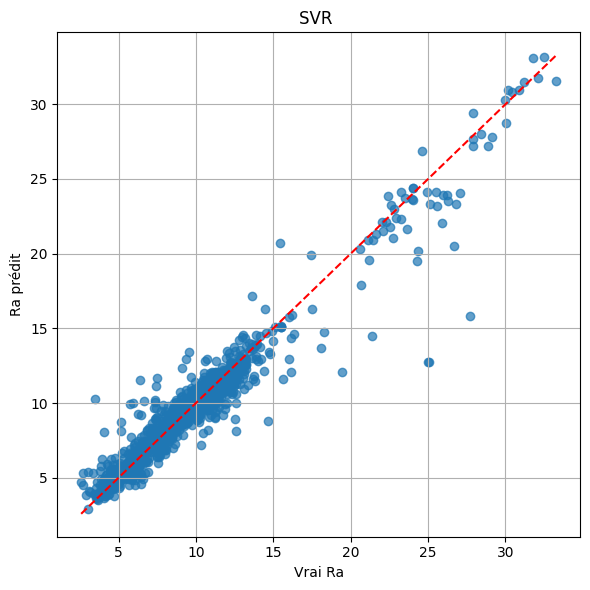

In [27]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1,0.5, 1,5,10],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf'],
     
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svr = SVR()
grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1
)

grid_svr.fit(X_train, y_train_bc.ravel())
best_svr = grid_svr.best_estimator_


y_pred_bc_svr = best_svr.predict(X_test)
y_pred_svr = inverse_box_cox(y_pred_bc_svr)


rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100

print("\n--- Meilleur SVR trouvé ---")
print(f"Best params: {grid_svr.best_params_}")
print(f"R2: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")
print(f"MAPE: {mape_svr:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
joblib.dump(best_svr, 'models_pvht_anova_gmm_gan/best_svr.joblib')

['models_pvht_anova_gmm_gan/best_svr.joblib']

In [29]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}


grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train_bc.ravel())


best_tree = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)


y_pred_bc_tree = best_tree.predict(X_test)
y_pred_tree = inverse_box_cox(y_pred_bc_tree)




rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print("\n--- Decision Tree ---")
print(f"R2: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MAPE: {mape_tree:.2f}%")




Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8}

--- Decision Tree ---
R2: 0.7947
RMSE: 2.0108
MAE: 1.0869
MAPE: 49.69%


In [31]:
joblib.dump(best_tree,"models_pvht_anova_gmm_gan/best_tree.joblib")

['models_pvht_anova_gmm_gan/best_tree.joblib']

In [9]:
!pip install pytorch-tabnet 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing in

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import numpy as np
from sklearn.metrics import mean_squared_error
import optuna

def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size": 50, "gamma": 0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }

    # Suggest batch size
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    model = TabNetRegressor(**params)
    
    model.fit(
        X_train=X_train,
        y_train=y_train_bc,
        eval_set=[(X_test, y_test_bc)],
        eval_metric=['rmse'],
        patience=40,
        max_epochs=500,
        batch_size=batch_size,
        virtual_batch_size=batch_size // 2,
        num_workers=0
    )
    
    preds = model.predict(X_test)
    score = np.sqrt(mean_squared_error(y_test_bc, preds)) 
    
    return score 

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-19 20:34:08,948] A new study created in memory with name: no-name-65442746-177d-4c37-8092-691061bc60ad



Early stopping occurred at epoch 238 with best_epoch = 198 and best_val_0_rmse = 0.34787


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-19 20:40:21,947] Trial 0 finished with value: 0.3478682256615853 and parameters: {'n_d': 64, 'n_a': 128, 'n_steps': 7, 'gamma': 1.127938265410409, 'lambda_sparse': 1.427240385968913e-05, 'lr': 0.008739558153884597, 'mask_type': 'entmax', 'batch_size': 256}. Best is trial 0 with value: 0.3478682256615853.



Early stopping occurred at epoch 495 with best_epoch = 455 and best_val_0_rmse = 0.39497


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-19 21:15:56,110] Trial 1 finished with value: 0.394974064759698 and parameters: {'n_d': 32, 'n_a': 256, 'n_steps': 10, 'gamma': 1.8450854560675647, 'lambda_sparse': 0.00021238941193449596, 'lr': 0.0002872796259777611, 'mask_type': 'sparsemax', 'batch_size': 128}. Best is trial 0 with value: 0.3478682256615853.


...

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-20 05:32:14,340] Trial 28 finished with value: 0.36947611415047515 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 9, 'gamma': 1.1441043692976487, 'lambda_sparse': 2.932910512471912e-06, 'lr': 0.004417940114752872, 'mask_type': 'entmax', 'batch_size': 64}. Best is trial 14 with value: 0.3340554982289396.



Early stopping occurred at epoch 230 with best_epoch = 190 and best_val_0_rmse = 0.33626


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-20 05:50:58,989] Trial 29 finished with value: 0.3362582654046185 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 7, 'gamma': 1.0071434736803018, 'lambda_sparse': 7.074202067762932e-06, 'lr': 0.00766087272652222, 'mask_type': 'entmax', 'batch_size': 64}. Best is trial 14 with value: 0.3340554982289396.



Early stopping occurred at epoch 206 with best_epoch = 166 and best_val_0_rmse = 0.34663


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-20 06:11:52,325] Trial 30 finished with value: 0.34663113283572794 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 1.0124762624738806, 'lambda_sparse': 8.014857959625972e-06, 'lr': 0.006954117214644972, 'mask_type': 'entmax', 'batch_size': 64}. Best is trial 14 with value: 0.3340554982289396.


In [11]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
tabnet_model = TabNetRegressor(
    n_d=128,
    n_a=128,
    n_steps=7,
    gamma=1.0071434736803018,
    lambda_sparse=7.074202067762932e-06,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.00766087272652222),
    mask_type='entmax'
)


tabnet_model.fit(
    X_train,
    y_train_bc,
    eval_set=[(X_test, y_test_bc)],
    eval_metric=['rmse'],
    patience=40,
    max_epochs=500,
    batch_size=64,
    virtual_batch_size=32,
    num_workers=0
)

y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc)


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 6.41164 | val_0_rmse: 1.44266 |  0:00:04s
epoch 1  | loss: 1.76615 | val_0_rmse: 1.10966 |  0:00:08s
epoch 2  | loss: 1.30484 | val_0_rmse: 0.86049 |  0:00:13s
epoch 3  | loss: 0.85482 | val_0_rmse: 0.83818 |  0:00:17s
epoch 4  | loss: 0.81648 | val_0_rmse: 0.79702 |  0:00:22s
epoch 5  | loss: 0.70462 | val_0_rmse: 0.88719 |  0:00:26s
epoch 6  | loss: 0.65954 | val_0_rmse: 0.77293 |  0:00:30s
epoch 7  | loss: 0.59778 | val_0_rmse: 0.75467 |  0:00:34s
epoch 8  | loss: 0.55363 | val_0_rmse: 0.67135 |  0:00:39s
epoch 9  | loss: 0.555   | val_0_rmse: 0.59188 |  0:00:44s
epoch 10 | loss: 0.4729  | val_0_rmse: 0.58101 |  0:00:48s
epoch 11 | loss: 0.4687  | val_0_rmse: 0.60823 |  0:00:52s
epoch 12 | loss: 0.45347 | val_0_rmse: 0.56901 |  0:00:57s
epoch 13 | loss: 0.42864 | val_0_rmse: 0.63701 |  0:01:01s
epoch 14 | loss: 0.45457 | val_0_rmse: 0.65203 |  0:01:05s
epoch 15 | loss: 0.44082 | val_0_rmse: 0.5699  |  0:01:09s
epoch 16 | loss: 0.3784  | val_0_rmse: 0.68007 |  0:01:1

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.9294
RMSE: 1.1789
MAE: 0.7513
MAPE: 8.2965


In [13]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Séparation train/validation (pour l'optimisation)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train_bc, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'loss_function': 'RMSE',
        'verbose': 0
    }

    model = CatBoostRegressor(**params)
    model.fit(X_train_split, y_train_split, eval_set=(X_val_split, y_val_split), early_stopping_rounds=50)

    y_val_pred = model.predict(X_val_split)
    rmse = mean_squared_error(y_val_split, y_val_pred, squared=False)
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

print("Meilleurs hyperparamètres :")
print(study.best_params)


[I 2025-05-20 12:20:31,965] A new study created in memory with name: no-name-cae01e35-8a16-425e-acbc-5d0c829e63aa
[I 2025-05-20 12:20:51,495] Trial 0 finished with value: 0.4464766726731755 and parameters: {'iterations': 1232, 'learning_rate': 0.0026663629339160827, 'depth': 10, 'l2_leaf_reg': 0.2616161348509312, 'bagging_temperature': 0.6621701390173792, 'random_strength': 3.337774458252186}. Best is trial 0 with value: 0.4464766726731755.
[I 2025-05-20 12:21:02,662] Trial 1 finished with value: 0.3820592919326259 and parameters: {'iterations': 1450, 'learning_rate': 0.21028435173627777, 'depth': 12, 'l2_leaf_reg': 0.0033573854088218814, 'bagging_temperature': 0.07891381475127546, 'random_strength': 0.248678840236293}. Best is trial 1 with value: 0.3820592919326259.
[I 2025-05-20 12:24:00,230] Trial 2 finished with value: 0.3409272875279393 and parameters: {'iterations': 2763, 'learning_rate': 0.007356714610993139, 'depth': 12, 'l2_leaf_reg': 0.5542355009795086, 'bagging_temperature':

KeyboardInterrupt: 

In [14]:
best_params = {
    'iterations': 2762,
    'learning_rate': 0.024427251490219938,
    'depth': 12,
    'l2_leaf_reg': 0.020935560606996233,
    'bagging_temperature': 0.42320459830570567,
    'random_strength': 3.5670019300291234,
    'loss_function': 'RMSE',
    'verbose': 0
}


cat_model = CatBoostRegressor(**best_params)
cat_model.fit(X_train, y_train_bc)


y_pred_cat_bc = cat_model.predict(X_test)
y_pred_cat = inverse_box_cox(y_pred_cat_bc)


print("R2:", r2_score(y_test, y_pred_cat))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_cat)))
print("MAE:", mean_absolute_error(y_test, y_pred_cat))

R2: 0.9249895595327524
RMSE: 1.2152734976271917
MAE: 0.6829969238540134


In [15]:
joblib.dump(cat_model, "catboost_model.pkl")

['catboost_model.pkl']

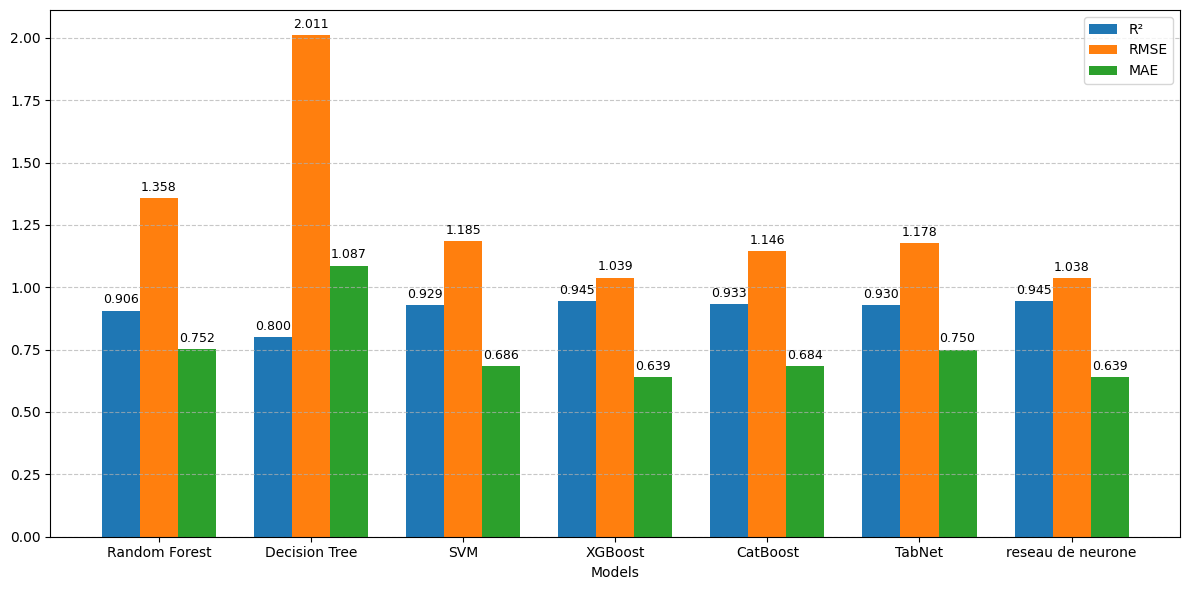

In [13]:
r2_rf =0.9064
rmse_rf= 1.3578
mae_rf=0.7523

r2_xgb= 0.9452
rmse_xgb= 1.0388
mae_xgb= 0.6391

r2_svr= 0.9287
rmse_svr=1.1848
mae_svr= 0.6856

r2_tabnet= 0.93
rmse_tabnet= 1.178
mae_tabnet= 0.75

r2_rn = 0.9452
mae_rn = 0.6391
rmse_rn = 1.038

rmse_tree = 2.0108
mae_tree = 1.0869
r2_tree = 0.80

r2_cat= 0.933
rmse_cat= 1.1463
mae_cat= 0.684

models = ['Random Forest', 'Decision Tree', 'SVM', 'XGBoost', 'CatBoost', 'TabNet', 'reseau de neurone']


r2_scores = [r2_rf, r2_tree, r2_svr, r2_xgb, r2_cat, r2_tabnet, r2_rn]
rmse_scores = [rmse_rf, rmse_tree, rmse_svr, rmse_xgb, rmse_cat, rmse_tabnet, rmse_rn]
mae_scores = [mae_rf, mae_tree, mae_svr, mae_xgb, mae_cat, mae_tabnet, mae_rn]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, r2_scores, width, label='R²')
bars2 = ax.bar(x, rmse_scores, width, label='RMSE')
bars3 = ax.bar(x + width, mae_scores, width, label='MAE')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

In [15]:
from itertools import combinations, product

import joblib
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

# === 1. Charger les modèles de base ===
rf = joblib.load("/kaggle/input/models_pvht_anova_gmm_gan/other/default/1/rf.joblib")
svr = joblib.load("/kaggle/input/models_pvht_anova_gmm_gan/other/default/1/best_svr.joblib")
xgb = joblib.load("/kaggle/input/models_pvht_anova_gmm_gan/other/default/1/xgb_best_model.joblib")
mlp = load_model("/kaggle/input/models_pvht_anova_gmm_gan/other/default/1/best_model.h5", compile=False)


base_models = {
    "rf": rf,
    "svr": svr,
    "xgb": xgb,
    "mlp": mlp,
    "cat": cat_model
}


X_meta_train, X_meta_test, y_meta_train_bc, y_meta_test_bc, y_meta_train, y_meta_test = train_test_split(
    X_test, y_test_bc, y_test, test_size=0.5, random_state=42
)

# === 3. Méta-modèles avec hyperparamètres ===
meta_model_configs = {
    "Ridge": [Ridge(alpha=a) for a in [0.1, 1.0, 10]],
    "Lasso": [Lasso(alpha=a, max_iter=10000) for a in [0.001, 0.01, 0.1]],
    "Bayesian": [BayesianRidge()],
    "SVR": [SVR(kernel=k, C=c, epsilon=e) for k in ['rbf'] for c in [1.0, 10.0] for e in [0.01, 0.1]]
}


results = []
best_r2 = -np.inf
best_combo = None

for r in range(2, len(base_models) + 1):
    for base_combo in combinations(base_models.items(), r):
        base_names = [name for name, _ in base_combo]
        
        # Générer prédictions manuellement
        def get_preds(name, model, X):
            pred = model.predict(X)
            return pred.squeeze() if name == "mlp" else pred
        
        train_preds = [get_preds(name, model, X_meta_train) for name, model in base_combo]
        test_preds  = [get_preds(name, model, X_meta_test)  for name, model in base_combo]

        X_stack_train = np.column_stack(train_preds)
        X_stack_test = np.column_stack(test_preds)

        for meta_name, models in meta_model_configs.items():
            for meta_model in models:
                full_name = f"{'+'.join(base_names)} | {meta_name}({meta_model.get_params()})"
                print(f"\n🚀 {full_name}")
                try:
                    meta_model.fit(X_stack_train, y_meta_train_bc)
                    pred_bc = meta_model.predict(X_stack_test)
                    pred = inverse_box_cox(pred_bc)

                    r2 = r2_score(y_meta_test, pred)
                    rmse = np.sqrt(mean_squared_error(y_meta_test, pred))
                    mae = mean_absolute_error(y_meta_test, pred)

                    print(f"✅ R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")

                    results.append({
                        "base_models": "+".join(base_names),
                        "meta_model": meta_name,
                        "meta_params": meta_model.get_params(),
                        "R2": r2,
                        "RMSE": rmse,
                        "MAE": mae
                    })

                    if r2 > best_r2:
                        best_r2 = r2
                        best_combo = full_name
                        joblib.dump(meta_model, "/kaggle/working/best_meta_model.joblib")

                except Exception as e:
                    print(f"❌ Erreur avec {full_name} : {e}")

# === 5. Résumé
df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\n🏆 Meilleure configuration :")
print(best_combo)
display(df.head(20))


2025-05-20 07:42:00.688427: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



🚀 rf+svr | Ridge({'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0148 | RMSE=4.4273 | MAE=2.8494

🚀 rf+svr | Ridge({'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0189 | RMSE=4.4182 | MAE=2.8418

🚀 rf+svr | Ridge({'alpha': 10, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0216 | RMSE=4.4120 | MAE=2.8427

🚀 rf+svr | Lasso({'alpha': 0.001, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False})
✅ R²=0.0158 | RMSE=4.4251 | MAE=2.8474

🚀 rf+svr | Lasso({'alpha': 0.01, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10000, 'positive': False, 'precompute': False, 'ra

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

✅ R²=0.1260 | RMSE=4.1700 | MAE=2.5670

🚀 rf+xgb | Ridge({'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0580 | RMSE=4.3292 | MAE=2.8482

🚀 rf+xgb | Ridge({'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0576 | RMSE=4.3300 | MAE=2.8473

🚀 rf+xgb | Ridge({'alpha': 10, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.0544 | RMSE=4.3375 | MAE=2.8422

🚀 rf+xgb | Lasso({'alpha': 0.001, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False})
✅ R²=0.0574 | RMSE=4.3306 | MAE=2.8469

🚀 rf+xgb | Lasso({'alpha': 0.01, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10000, 'pos

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

✅ R²=0.9374 | RMSE=1.1157 | MAE=0.7032
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

🚀 rf+svr+xgb+mlp+cat | Ridge({'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.9440 | RMSE=1.0558 | MAE=0.6528

🚀 rf+svr+xgb+mlp+cat | Ridge({'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.9440 | RMSE=1.0552 | MAE=0.6518

🚀 rf+svr+xgb+mlp+cat | Ridge({'alpha': 10, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})
✅ R²=0.9444 | RMSE=1.0521 | MAE=0.6446

🚀 rf+svr+xgb+mlp+cat | Lasso({'alpha': 0.001, 'copy_X': True, 'fit_intercept': True, 'max_iter': 10000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False})
✅ R²=0.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

✅ R²=0.9411 | RMSE=1.0827 | MAE=0.6943

🏆 Meilleure configuration :
svr+cat | Ridge({'alpha': 10, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001})


,base_models,meta_model,meta_params,R2,RMSE,MAE
68,svr+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944444,1.051344,0.643957
200,svr+mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944436,1.051416,0.643488
101,mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944431,1.051460,0.643529
255,rf+xgb+mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944363,1.052107,0.644580
277,rf+svr+xgb+mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944362,1.052114,0.644587
233,rf+svr+xgb+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944361,1.052126,0.644690
156,rf+xgb+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944361,1.052129,0.644694
244,rf+svr+mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944359,1.052142,0.643880
134,rf+svr+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944357,1.052160,0.644080
167,rf+mlp+cat,Ridge,"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.944354,1.052191,0.643923
